In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


print("success")

success


In [14]:
df = pd.read_csv('diabetes_dataset.csv')
df.head(10)

,Patient_ID,Age,Gender,BMI,Glucose_Level,Blood_Pressure,Insulin,Physical_Activity,Family_History,Diabetes_Outcome
0,P0001,58,F,36.4,151,102,98.5,86,Yes,1
1,P0002,71,M,28.3,185,80,294.3,29,No,0
2,P0003,48,M,27.1,172,82,186.5,108,Yes,1
3,P0004,34,F,24.0,86,139,181.0,46,No,0
4,P0005,62,M,19.2,83,106,228.2,86,Yes,0
5,P0006,27,F,37.0,177,74,246.4,48,Yes,1
6,P0007,40,M,35.9,114,84,202.1,46,Yes,1
7,P0008,58,F,40.0,167,95,51.5,83,Yes,1
8,P0009,77,F,39.9,106,134,111.4,81,Yes,1
9,P0010,38,F,30.2,177,110,279.5,17,No,1


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Patient_ID         500 non-null    object 
 1   Age                500 non-null    int64  
 2   Gender             500 non-null    object 
 3   BMI                500 non-null    float64
 4   Glucose_Level      500 non-null    int64  
 5   Blood_Pressure     500 non-null    int64  
 6   Insulin            500 non-null    float64
 7   Physical_Activity  500 non-null    int64  
 8   Family_History     500 non-null    object 
 9   Diabetes_Outcome   500 non-null    int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 39.2+ KB


In [16]:
## Checking for missing Values

df.isnull().sum()

Patient_ID           0
Age                  0
Gender               0
BMI                  0
Glucose_Level        0
Blood_Pressure       0
Insulin              0
Physical_Activity    0
Family_History       0
Diabetes_Outcome     0
dtype: int64

In [17]:
## Checking for Duplicate Values
df.duplicated().sum()

np.int64(0)

In [18]:
df.describe()

,Age,BMI,Glucose_Level,Blood_Pressure,Insulin,Physical_Activity,Diabetes_Outcome
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,50.396000,28.594200,132.898000,106.614000,159.737600,57.66400,0.542000
std,17.335982,6.288902,38.211462,29.182121,81.385927,33.91205,0.498732
min,20.000000,18.100000,70.000000,60.000000,15.400000,0.00000,0.000000
25%,36.750000,22.975000,100.000000,80.000000,89.175000,29.00000,0.000000
50%,51.000000,28.400000,131.500000,104.000000,162.450000,55.00000,1.000000
75%,65.000000,33.925000,166.000000,132.000000,230.325000,86.00000,1.000000
max,79.000000,40.000000,199.000000,159.000000,299.500000,119.00000,1.000000


In [19]:
df.describe(include='object')

,Patient_ID,Gender,Family_History
count,500,500,500
unique,500,2,2
top,P0500,M,Yes
freq,1,252,296


In [23]:
df.describe(include='float')

,BMI,Insulin
count,500.000000,500.000000
mean,28.594200,159.737600
std,6.288902,81.385927
min,18.100000,15.400000
25%,22.975000,89.175000
50%,28.400000,162.450000
75%,33.925000,230.325000
max,40.000000,299.500000


In [24]:
df.describe(include='int64')

,Age,Glucose_Level,Blood_Pressure,Physical_Activity,Diabetes_Outcome
count,500.000000,500.000000,500.000000,500.00000,500.000000
mean,50.396000,132.898000,106.614000,57.66400,0.542000
std,17.335982,38.211462,29.182121,33.91205,0.498732
min,20.000000,70.000000,60.000000,0.00000,0.000000
25%,36.750000,100.000000,80.000000,29.00000,0.000000
50%,51.000000,131.500000,104.000000,55.00000,1.000000
75%,65.000000,166.000000,132.000000,86.00000,1.000000
max,79.000000,199.000000,159.000000,119.00000,1.000000


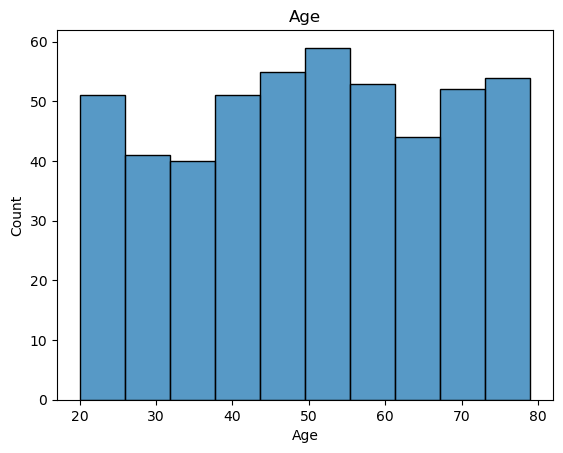

In [25]:
ax = sns.histplot(x = "Age",
                data = df,)
plt.title("Age")
plt.show()

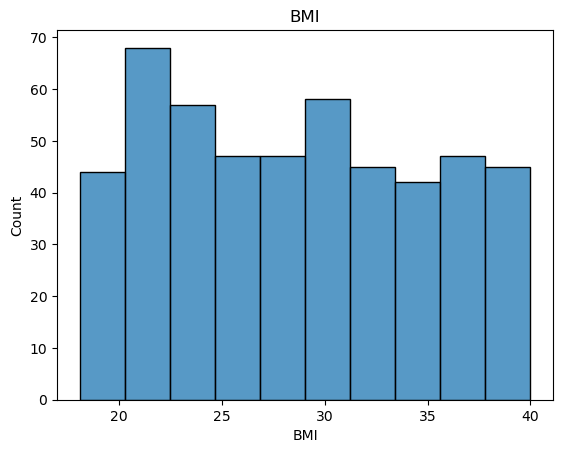

In [26]:
ax = sns.histplot(x = "BMI",
                data = df,
                )

plt.title("BMI")
plt.show()

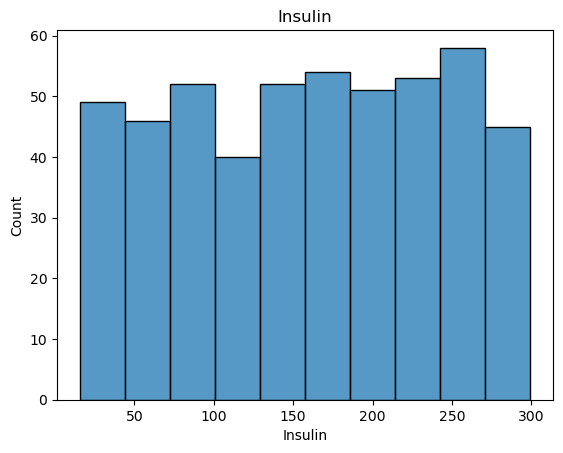

In [27]:
ax = sns.histplot(x = "Insulin",
                data = df,
                )

plt.title("Insulin")
plt.show()

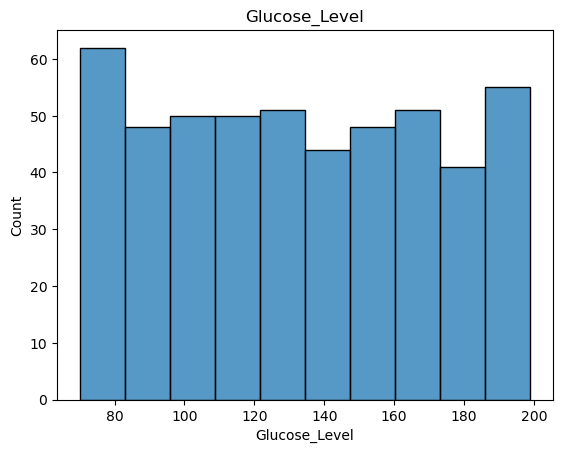

In [28]:
ax = sns.histplot(x = "Glucose_Level",
                data = df,
                )

plt.title("Glucose_Level")
plt.show()

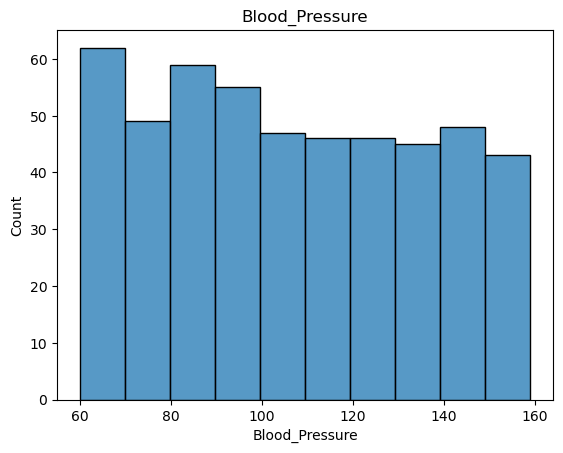

In [29]:
ax = sns.histplot(x = "Blood_Pressure",
                data = df,
                )

plt.title("Blood_Pressure")
plt.show()

In [30]:
# Bins: 0-150: Insufficiently Active |150-300: Highly Active

bins = [0, 150, 300]
labels = ['Insufficiently Active', 'Highly Active']

# Saving to a new column name to protect original data
df['Physical_State'] = pd.cut(df['Physical_Activity'], bins=bins, labels=labels, include_lowest=True)

# Quick check to see the distribution
print(df['Physical_State'].value_counts())

Physical_State
Insufficiently Active    500
Highly Active              0
Name: count, dtype: int64


In [31]:
df['Physical_Activity'].describe()


count    500.00000
mean      57.66400
std       33.91205
min        0.00000
25%       29.00000
50%       55.00000
75%       86.00000
max      119.00000
Name: Physical_Activity, dtype: float64

In [32]:
df['Physical_Activity'].unique()


array([ 86,  29, 108,  46,  48,  83,  81,  17,  65,  67,  93,  32,  35,
       100,  18, 110,  27,  39, 112,  96,  75, 114,  14,  40,  38,   1,
        62,  28, 104,  73,  50,  74,  76,   9,  13, 117,  72,   2,  69,
        26, 116,  92,  37,  15,  80,  11,  34, 106,  64,  54,  44,  78,
        89,  84,  61,  94,  24,  22,  23,  20,  53,  98, 118,  52, 101,
        59, 107,  97,  31,  66,  43, 103,  47,  56,  99,  33,  55,  36,
         6,  19,  91,  42,  90,  10,  63,  68,   7, 115,  30,   3,  49,
       119,  87,  58,  25,  45, 105,   5,  41,  16,  95, 111,  21,  12,
        85, 102,   0,   4,  51, 113,  77,  71, 109,  60,  79,  70,   8,
        82])

In [33]:
df.head()

,Patient_ID,Age,Gender,BMI,Glucose_Level,Blood_Pressure,Insulin,Physical_Activity,Family_History,Diabetes_Outcome,Physical_State
0,P0001,58,F,36.4,151,102,98.5,86,Yes,1,Insufficiently Active
1,P0002,71,M,28.3,185,80,294.3,29,No,0,Insufficiently Active
2,P0003,48,M,27.1,172,82,186.5,108,Yes,1,Insufficiently Active
3,P0004,34,F,24.0,86,139,181.0,46,No,0,Insufficiently Active
4,P0005,62,M,19.2,83,106,228.2,86,Yes,0,Insufficiently Active


In [34]:
# Bins: 0-99.9: Normal | 100-125.9: Prediabetic | 126-300: Diabetic
# We start at 0 to make sure the minimum of 70 is included in 'Normal'
bins = [0, 99.9, 125.9, 200]
labels = ['Normal', 'Prediabetic', 'Diabetic']

# Saving to a new column name to protect original data
df['Glucose_Status'] = pd.cut(df['Glucose_Level'], bins=bins, labels=labels, include_lowest=True)

# Quick check to see the distribution
print(df['Glucose_Status'].value_counts())

Glucose_Status
Diabetic       277
Normal         124
Prediabetic     99
Name: count, dtype: int64


In [35]:
# Create Insulin categories based on WHO standards
conditions = [
    (df['Insulin'] < 35),
    (df['Insulin'] >= 35) & (df['Insulin'] < 70),
    (df['Insulin'] >= 70) & (df['Insulin'] < 105),
    (df['Insulin'] > 105)
]
categories = ['Optimal', 'Normal', 'Early-Resistance', 'High Resistance']
df['Insulin_category'] = np.select(conditions, categories, default='Unknown')

print("\nCounts of Insulin Categories:")
print(df['Insulin_category'].value_counts())


Counts of Insulin Categories:
Insulin_category
High Resistance     346
Early-Resistance     62
Normal               57
Optimal              35
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_53376\902044961.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Glucose_Status', y='Age', palette='Set2')


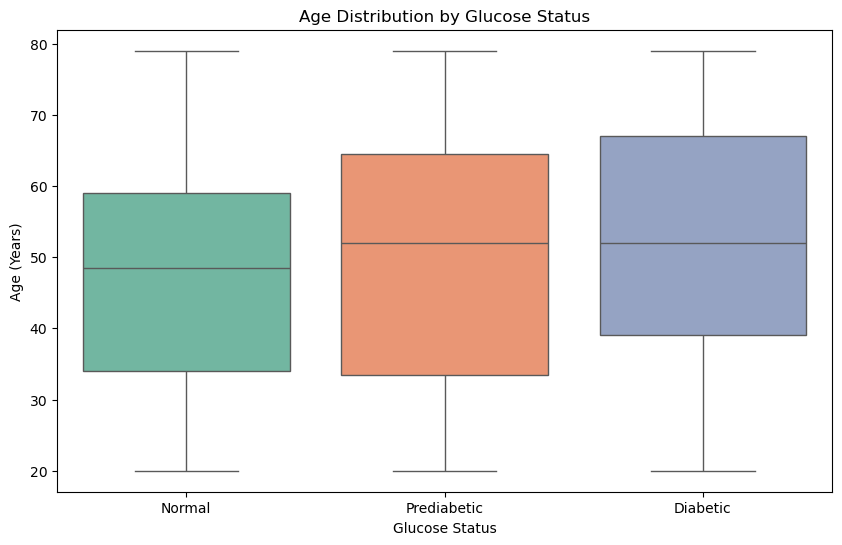

In [36]:


plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='Glucose_Status', y='Age', palette='Set2')

plt.title('Age Distribution by Glucose Status')
plt.xlabel('Glucose Status')
plt.ylabel('Age (Years)')

plt.show()

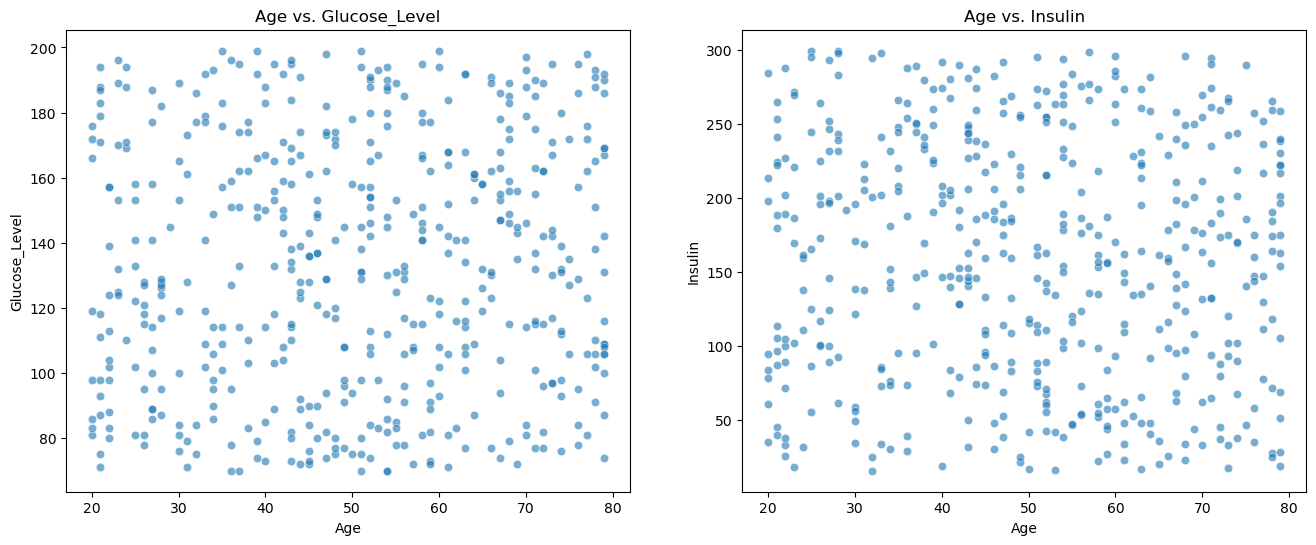

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x='Age', y='Glucose_Level', data=df, ax=axes[0], alpha=0.6)
axes[0].set_title('Age vs. Glucose_Level')

sns.scatterplot(x='Age', y='Insulin', data=df, ax=axes[1], alpha=0.6)
axes[1].set_title('Age vs. Insulin')
plt.show()

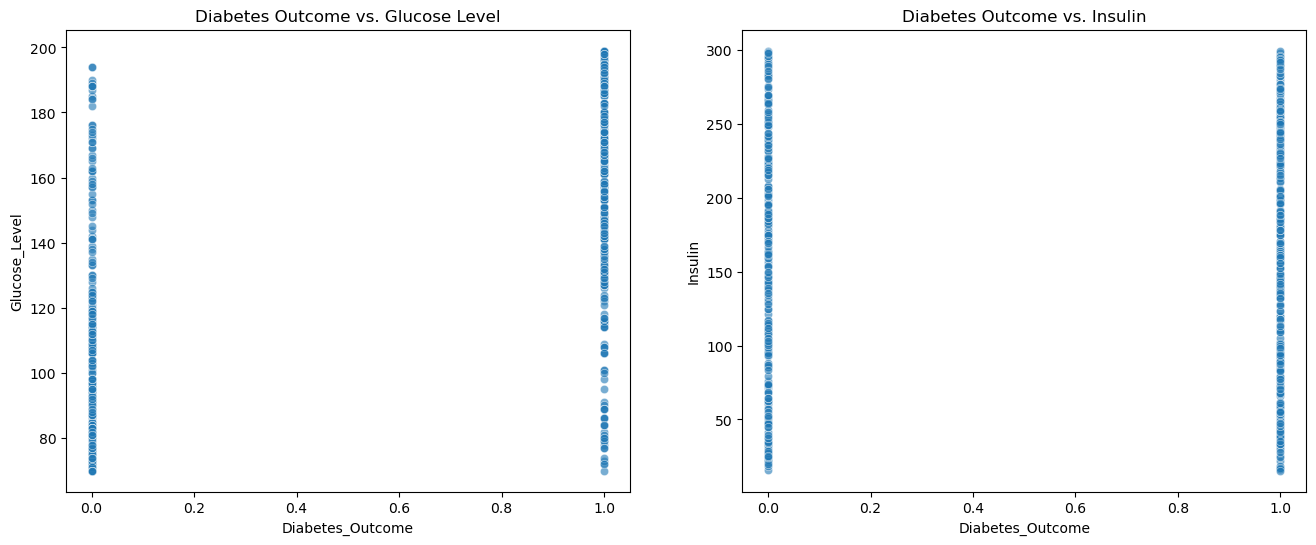

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x='Diabetes_Outcome', y='Glucose_Level', data=df, ax=axes[0], alpha=0.6)
axes[0].set_title('Diabetes Outcome vs. Glucose Level')

sns.scatterplot(x='Diabetes_Outcome', y='Insulin', data=df, ax=axes[1], alpha=0.6)
axes[1].set_title('Diabetes Outcome vs. Insulin')
plt.show()

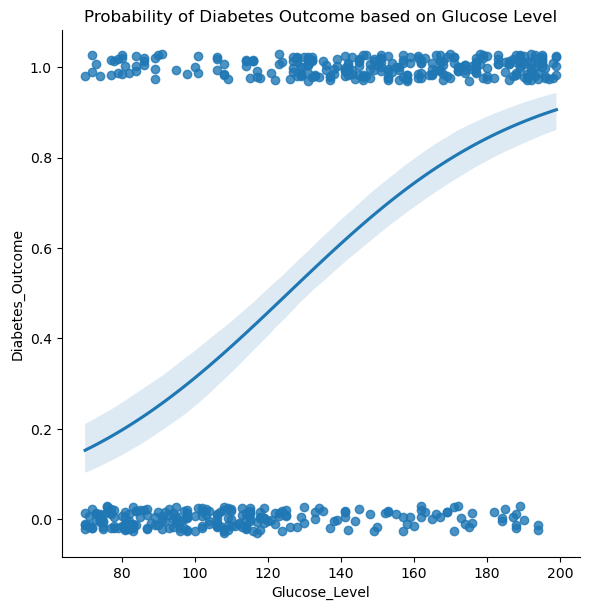

In [39]:


# height and aspect control the size
sns.lmplot(data=df, x='Glucose_Level', y='Diabetes_Outcome', logistic=True, y_jitter=0.03, height=6)

plt.title('Probability of Diabetes Outcome based on Glucose Level')
plt.show()

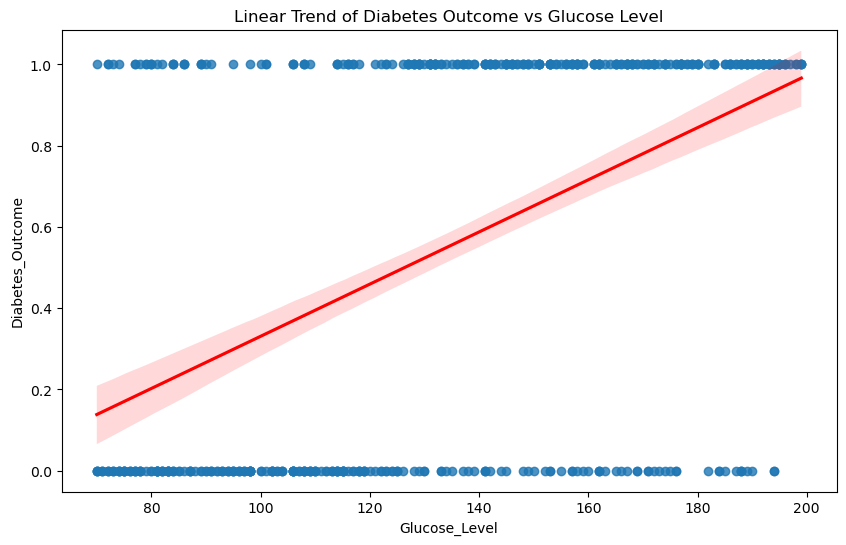

In [40]:
plt.figure(figsize=(10, 6))

# regplot is a simpler version of lmplot
sns.regplot(data=df, x='Glucose_Level', y='Diabetes_Outcome', line_kws={"color": "red"})

plt.title('Linear Trend of Diabetes Outcome vs Glucose Level')
plt.show()

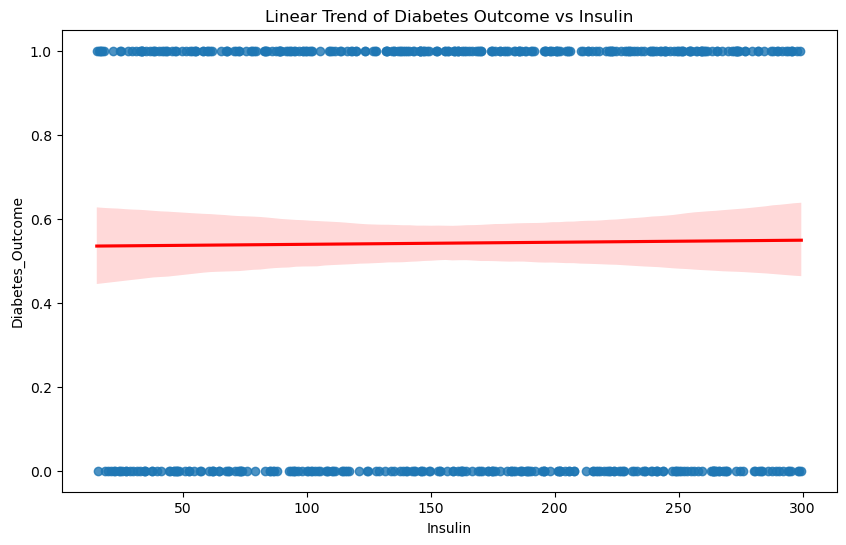

In [41]:
plt.figure(figsize=(10, 6))

# regplot is a simpler version of lmplot
sns.regplot(data=df, x='Insulin', y='Diabetes_Outcome', line_kws={"color": "red"})

plt.title('Linear Trend of Diabetes Outcome vs Insulin')
plt.show()

In [42]:
list(df.columns)

['Patient_ID',
 'Age',
 'Gender',
 'BMI',
 'Glucose_Level',
 'Blood_Pressure',
 'Insulin',
 'Physical_Activity',
 'Family_History',
 'Diabetes_Outcome',
 'Physical_State',
 'Glucose_Status',
 'Insulin_category']

In [43]:
# 1. Categorize Glucose safely
# Bins: 0-99.9 (Normal), 100-125.9 (Prediabetic), 126-200 (Diabetic)
bins = [0, 99.9, 125.9, 200]
labels = ['Normal', 'Prediabetic', 'Diabetic']
df['glucose_group'] = pd.cut(df['Glucose_Level'], bins=bins, labels=labels, include_lowest=True)

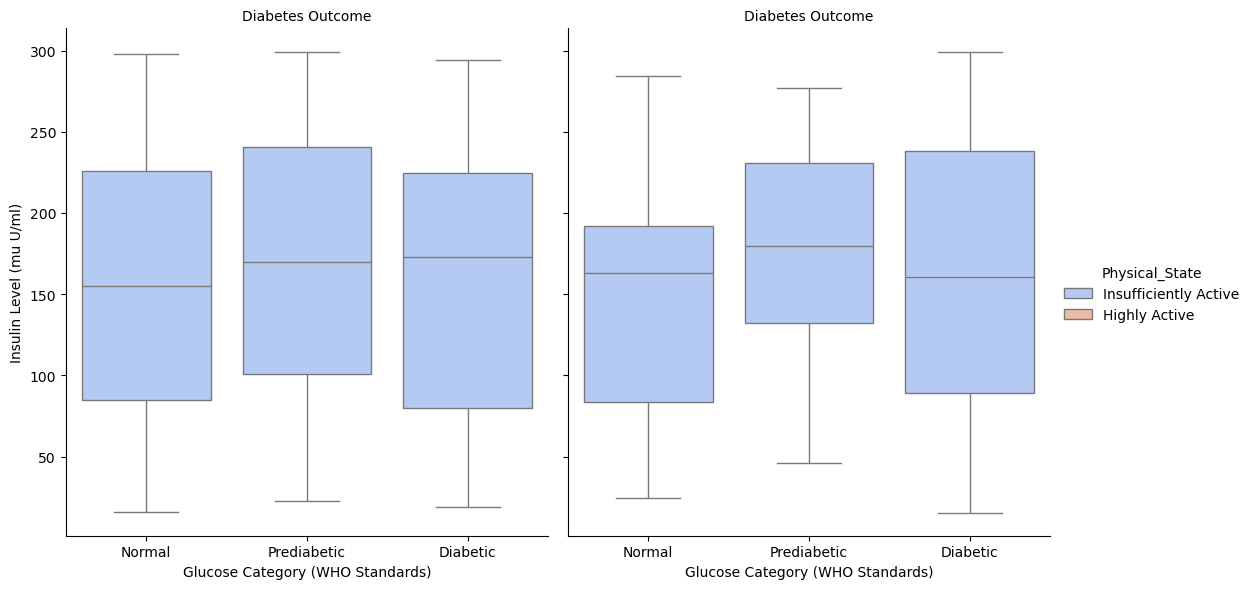

In [44]:
# 2. The Four-Way Boxplot
g = sns.catplot(
    data=df,
    x='glucose_group',
    y='Insulin',
    hue= 'Physical_State',
    col='Diabetes_Outcome',
    kind='box',
    palette='coolwarm',
    height=6,
    aspect=0.9
)

# 3. Customizing labels for report
g.set_axis_labels("Glucose Category (WHO Standards)", "Insulin Level (mu U/ml)")
g.set_titles("Diabetes Outcome")
g._legend.set_title("Physical_State")

# Adjusting Y-axis if high insulin outliers
# plt.ylim(0, 500)

plt.show()

In [45]:
from scipy import stats

# 1. Separate the original Glucose numbers into two groups based on the Outcome
group_no_diabetes = df[df['Diabetes_Outcome'] == 0]['Glucose_Level']
group_with_diabetes = df[df['Diabetes_Outcome'] == 1]['Glucose_Level']

# 2. Perform the Independent T-Test
t_stat, p_val = stats.ttest_ind(group_with_diabetes, group_no_diabetes, equal_var=False)

# 3. Display results
print(f"Average Glucose (No Diabetes): {group_no_diabetes.mean():.2f}")
print(f"Average Glucose (Diabetes): {group_with_diabetes.mean():.2f}")
print("-" * 30)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")
print(f"Conclusion: {'Significant difference' if p_val < 0.05 else 'No significant difference'}")

Average Glucose (No Diabetes): 112.46
Average Glucose (Diabetes): 150.17
------------------------------
T-statistic: 12.6475
P-value: 6.4527e-32
Conclusion: Significant difference


# Preprocessing Stage#

In [46]:
df_processed = df.drop('Patient_ID', axis=1)

X = df_processed.drop('Diabetes_Outcome', axis=1)
y = df_processed['Diabetes_Outcome']

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [49]:
numerical_features = ['Age', 'BMI', 'Glucose_Level', 'Blood_Pressure', 'Insulin', 'Physical_Activity']
categorical_features = ['Gender', 'Family_History', 'Physical_State', 'Glucose_Status', 'Insulin_category', 'glucose_group']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [50]:
X_processed_sparse = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)

# Combine numerical and categorical feature names
all_feature_names = numerical_features + list(feature_names)

X_processed = pd.DataFrame(X_processed_sparse, columns=all_feature_names)

# Spliting the data set#

In [51]:
from sklearn.model_selection import train_test_split

X_train_processed, X_test_processed, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

# Model Training#
The Following models are trained:

- XGBoost Classifier.
- CatBoost Classifier.
- LightGBM Classifier
- Logistic Regression
- Random Forest
- Support Vector Machine
- K-Nearest Neighbors.


In [60]:
# Install all the required ML packages for your classifiers
%pip install --user scikit-learn xgboost catboost lightgbm --quiet
print('success')

Note: you may need to restart the kernel to use updated packages.
success


In [61]:
!pip install xgboost
import xgboost
print(xgboost.__version__)

3.1.3


Access is denied.


In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [63]:
log_reg_model = LogisticRegression(random_state=42)
random_forest_model = RandomForestClassifier(random_state=42)
svc_model = SVC(random_state=42, probability=True)
knn_model = KNeighborsClassifier()
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
catboost_model = CatBoostClassifier(random_state=42, verbose=0, eval_metric='Logloss')
lgbm_model = LGBMClassifier(random_state=42, objective='binary')

In [64]:
import lightgbm as lgb

log_reg_model.fit(X_train_processed, y_train)
random_forest_model.fit(X_train_processed, y_train)
svc_model.fit(X_train_processed, y_train)
knn_model.fit(X_train_processed, y_train)
xgb_model.fit(X_train_processed, y_train)
catboost_model.fit(X_train_processed, y_train)
lgbm_model.fit(X_train_processed, y_train, eval_set=[(X_test_processed, y_test)],
               eval_metric='auc', callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)])

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 217, number of negative: 183
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 582
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 20
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.542500 -> initscore=0.170411
[LightGBM] [Info] Start training from score 0.170411
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

LGBMClassifier(objective='binary', random_state=42)

# Model Evaluation#
- Evaluating the performance of all trained models using relevant classification metrics
- (e.g., accuracy, precision, recall, F1-score, ROC-AUC).

In [65]:
models = {
    'Logistic Regression': log_reg_model,
    'Random Forest': random_forest_model,
    'SVM': svc_model,
    'K-Nearest Neighbors': knn_model,
    'XGBoost': xgb_model,
    'CatBoost': catboost_model,
    'LightGBM': lgbm_model
}

In [67]:
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test_processed)

    if name == 'SVM':
        y_pred_proba = model.predict_proba(X_test_processed)[:, 1]
    else:
        y_pred_proba = model.predict_proba(X_test_processed)[:, 1] # Probability of the positive class

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

# The printing logic will remain in the next cell, which iterates over the now fully populated 'results' dictionary.

In [68]:
print("--- Model Evaluation Results ---")
for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    for metric_name, value in metrics.items():
        print(f" {metric_name}: {value:.2f}")

--- Model Evaluation Results ---

Logistic Regression:
 Accuracy: 0.96
 Precision: 0.93
 Recall: 1.00
 F1-Score: 0.96
 ROC-AUC: 1.00

Random Forest:
 Accuracy: 0.99
 Precision: 0.98
 Recall: 1.00
 F1-Score: 0.99
 ROC-AUC: 1.00

SVM:
 Accuracy: 0.94
 Precision: 0.91
 Recall: 0.98
 F1-Score: 0.95
 ROC-AUC: 1.00

K-Nearest Neighbors:
 Accuracy: 0.91
 Precision: 0.89
 Recall: 0.94
 F1-Score: 0.92
 ROC-AUC: 0.97

XGBoost:
 Accuracy: 0.99
 Precision: 0.98
 Recall: 1.00
 F1-Score: 0.99
 ROC-AUC: 1.00

CatBoost:
 Accuracy: 0.99
 Precision: 0.98
 Recall: 1.00
 F1-Score: 0.99
 ROC-AUC: 1.00

LightGBM:
 Accuracy: 1.00
 Precision: 1.00
 Recall: 1.00
 F1-Score: 1.00
 ROC-AUC: 1.00


# Comparing and Visualizing Results#
- The evaluation metrics for all models using barchart to identify the best-performing model.

In [69]:
results_df = pd.DataFrame.from_dict(results, orient='index')

print("--- Model Performance Comparison ---")
print(results_df)

--- Model Performance Comparison ---
                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Logistic Regression      0.96   0.931034  1.000000  0.964286  0.998390
Random Forest            0.99   0.981818  1.000000  0.990826  0.999597
SVM                      0.94   0.913793  0.981481  0.946429  0.995974
K-Nearest Neighbors      0.91   0.894737  0.944444  0.918919  0.971216
XGBoost                  0.99   0.981818  1.000000  0.990826  1.000000
CatBoost                 0.99   0.981818  1.000000  0.990826  1.000000
LightGBM                 1.00   1.000000  1.000000  1.000000  1.000000


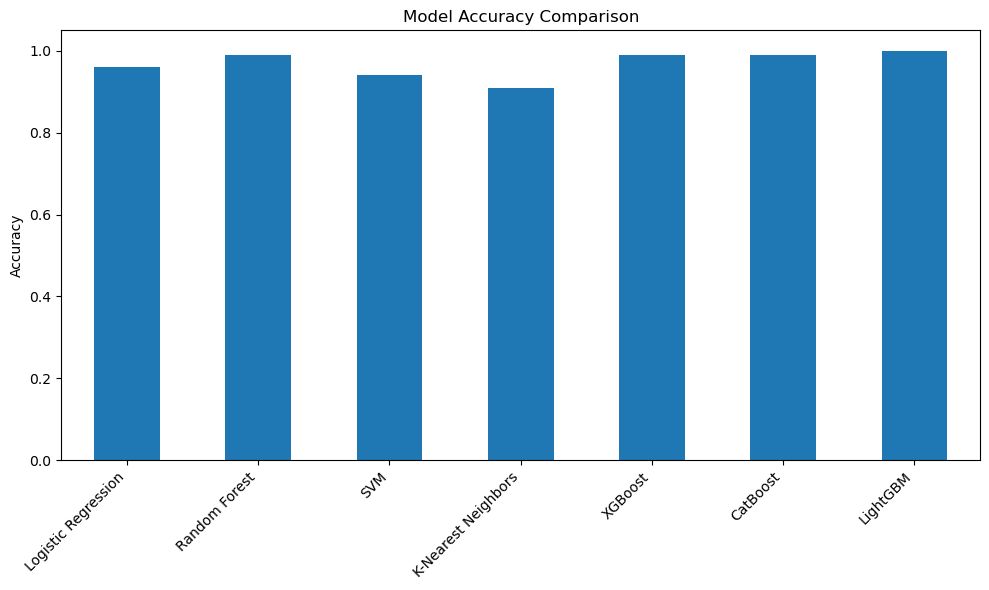

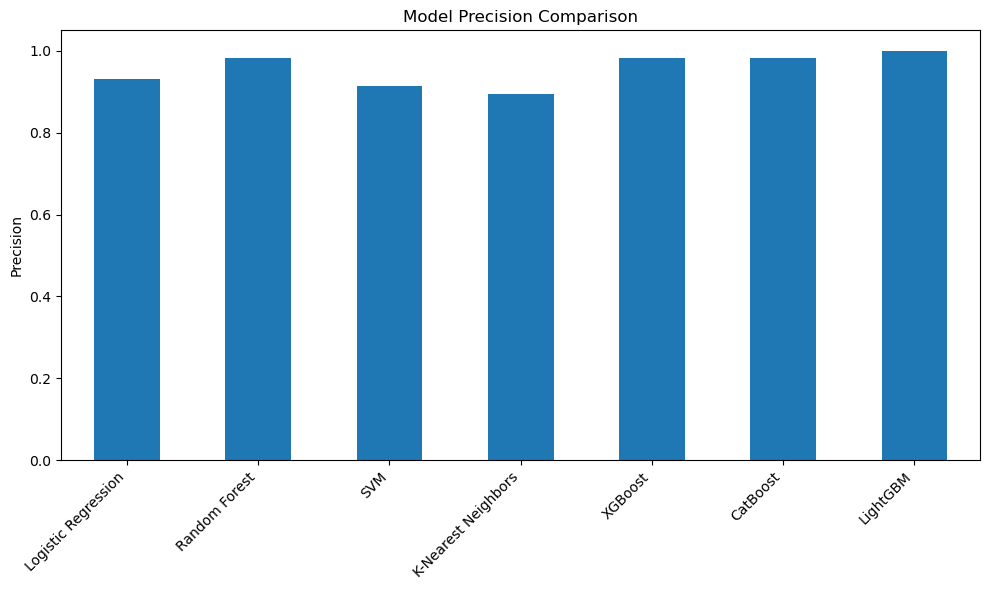

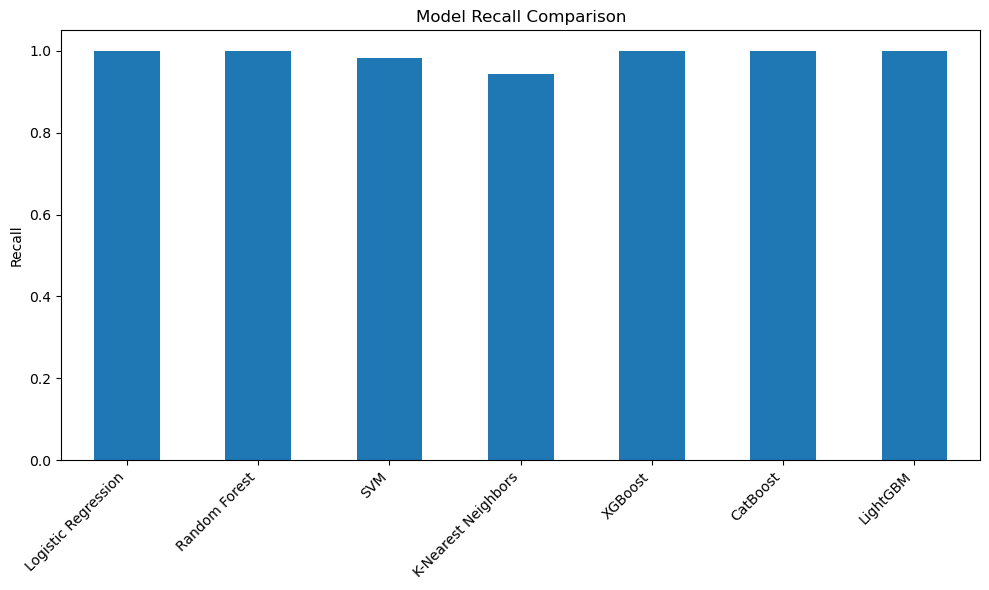

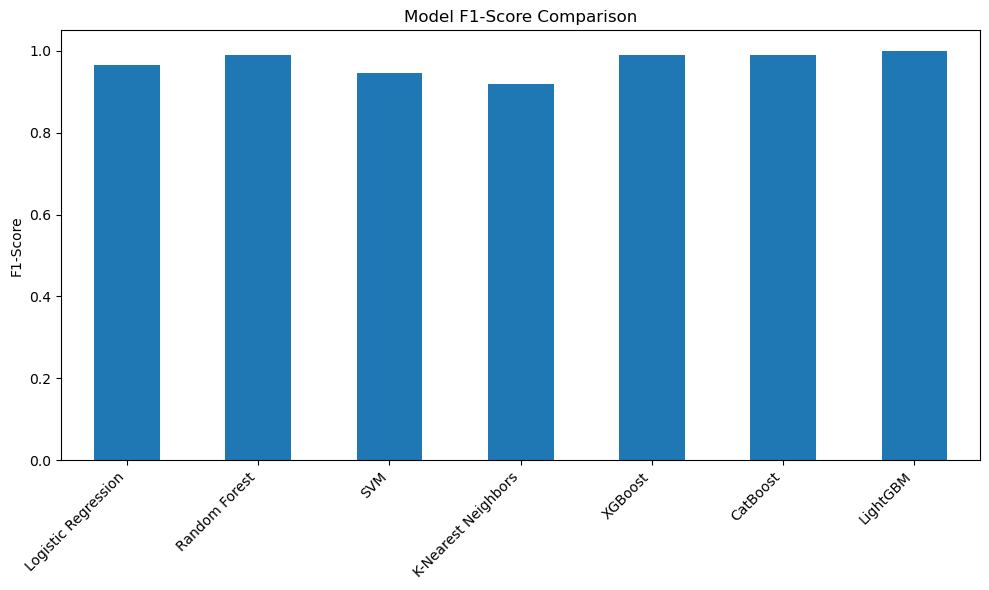

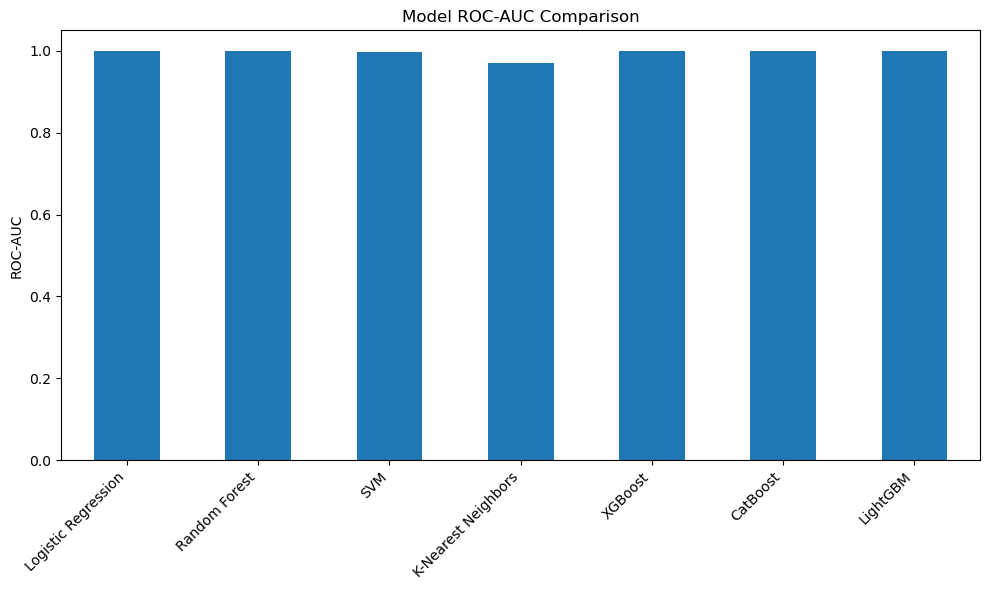

In [70]:
for metric in results_df.columns:
    plt.figure(figsize=(10, 6))
    results_df[metric].plot.bar()
    plt.title(f'Model {metric} Comparison')
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

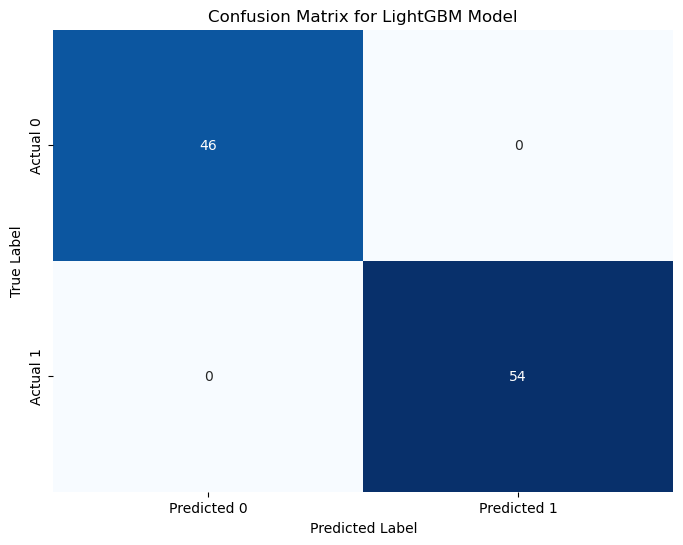

In [71]:
from sklearn.metrics import confusion_matrix

# Get predictions from the best LightGBM model
y_pred_lgbm = lgbm_model.predict(X_test_processed)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_lgbm)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for LightGBM Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Hyperparameter Tuning 
- The Optuna hyperparameter optimization study was executed to find the best set of parameters for the LightGBM model.

In [73]:
%pip install optuna

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.




   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ---------

In [74]:
import optuna


def objective(trial):
    # hyperparameters to tune for LightGBM
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42,
        'n_jobs': -1 # Use all available cores
    }

    # Initialize and train LightGBM model within the objective function
    model = LGBMClassifier(**params)
    model.fit(X_train_processed, y_train)

    # Predict probabilities on the test set
    y_pred_proba = model.predict_proba(X_test_processed)[:, 1]

    # Calculate ROC-AUC score
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    return roc_auc

In [75]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Optuna study completed.")
print(f"Best trial value (ROC-AUC): {study.best_value:.4f}")
print("Best trial parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-02-06 12:31:49,332] A new study created in memory with name: no-name-bbe43f58-4cbb-410d-a827-fb5899babd08
[I 2026-02-06 12:31:49,494] Trial 0 finished with value: 1.0 and parameters: {'n_estimators': 371, 'learning_rate': 0.1677363230252397, 'num_leaves': 34, 'max_depth': 14, 'min_child_samples': 14, 'subsample': 0.934148771184333, 'colsample_bytree': 0.920645222089217, 'reg_alpha': 0.7173243947807727, 'reg_lambda': 0.25137036029555504}. Best is trial 0 with value: 1.0.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 217, number of negative: 183
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000633 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 582
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.542500 -> initscore=0.170411
[LightGBM] [Info] Start training from score 0.170411
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2026-02-06 12:31:49,700] Trial 1 finished with value: 1.0 and parameters: {'n_estimators': 741, 'learning_rate': 0.026690869968879184, 'num_leaves': 88, 'max_depth': 12, 'min_child_samples': 24, 'subsample': 0.7364249050695062, 'colsample_bytree': 0.8720708827865649, 'reg_alpha': 0.5153475632050559, 'reg_lambda': 0.6962100113183566}. Best is trial 0 with value: 1.0.
[I 2026-02-06 12:31:49,777] Trial 2 finished with value: 1.0 and parameters: {'n_estimators': 272, 'learning_rate': 0.02021624887130763, 'num_leaves': 154, 'max_depth': 10, 'min_child_samples': 43, 'subsample': 0.9240606137749744, 'colsample_bytree': 0.6412774310742164, 'reg_alpha': 0.8153139112071319, 'reg_lambda': 0.36694060251284377}. Best is trial 0 with value: 1.0.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-02-06 12:31:50,025] Trial 3 finished with value: 1.0 and parameters: {'n_estimators': 459, 'learning_rate': 0.019941759208864134, 'num_leaves': 180, 'max_depth': 5, 'min_child_samples': 34, 'subsample': 0.6449182692505171, 'colsample_bytree': 0.708097121591543, 'reg_alpha': 0.8207977867713689, 'reg_lambda': 0.5453517140200574}. Best is trial 0 with value: 1.0.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-02-06 12:31:56,523] Trial 48 finished with value: 1.0 and parameters: {'n_estimators': 788, 'learning_rate': 0.05576369916318372, 'num_leaves': 82, 'max_depth': 6, 'min_child_samples': 10, 'subsample': 0.6798781351911412, 'colsample_bytree': 0.6156400217497071, 'reg_alpha': 0.23219099582580865, 'reg_lambda': 0.5368519798629099}. Best is trial 0 with value: 1.0.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 217, number of negative: 183
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000133 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 582
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.542500 -> initscore=0.170411
[LightGBM] [Info] Start training from score 0.170411
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2026-02-06 12:31:56,660] Trial 49 finished with value: 1.0 and parameters: {'n_estimators': 479, 'learning_rate': 0.08127464940545676, 'num_leaves': 34, 'max_depth': 12, 'min_child_samples': 56, 'subsample': 0.7518093474224425, 'colsample_bytree': 0.9782916999873579, 'reg_alpha': 0.9424469672214146, 'reg_lambda': 0.9888637829159524}. Best is trial 0 with value: 1.0.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 217, number of negative: 183
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000130 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 576
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.542500 -> initscore=0.170411
[LightGBM] [Info] Start training from score 0.170411
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

# rain LightGBM with best parameters
- Initializing and training a new LightGBM model using the optimal hyperparameters identified by Optuna


In [76]:
best_params = study.best_params
best_params['random_state'] = 42
best_params['objective'] = 'binary'

# Initialize and train LightGBM model with best parameters
lgbm_tuned_model = LGBMClassifier(**best_params)
lgbm_tuned_model.fit(X_train_processed, y_train)

print("LightGBM model initialized and trained with optimal hyperparameters successfully.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 217, number of negative: 183
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000128 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 582
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.542500 -> initscore=0.170411
[LightGBM] [Info] Start training from score 0.170411
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

In [77]:
y_pred_tuned = lgbm_tuned_model.predict(X_test_processed)
y_pred_proba_tuned = lgbm_tuned_model.predict_proba(X_test_processed)[:, 1]

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned)

print("--- Tuned LightGBM Model Performance ---")
print(f"Accuracy:  {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall:    {recall_tuned:.4f}")
print(f"F1-Score:  {f1_tuned:.4f}")
print(f"ROC-AUC:   {roc_auc_tuned:.4f}")

--- Tuned LightGBM Model Performance ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000


In [78]:
import joblib

model_filename = 'lgbm_tuned_model.pkl'

joblib.dump(lgbm_tuned_model, model_filename)

['lgbm_tuned_model.pkl']

In [79]:
import joblib

joblib.dump(preprocessor, 'preprocessor.pkl')

print("Preprocessor saved successfully as 'preprocessor.pkl'")

Preprocessor saved successfully as 'preprocessor.pkl'
